# Customer Transaction & Behavior Analysis
**DSA1080A – Programming for Data Science | Spring Semester 2026 | USIU-Africa**

**Student:** Gad Rubuye | **Student ID:** 677569


## Section 1 — Setup & Imports

In [2]:
# Importing all libraries required across the full project.
# Grouped by purpose for clarity and maintainability.

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings — ensures plots render inline in Jupyter
%matplotlib inline

# Setting a clean, consistent visual style for all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Suppressing non-critical warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Section 2 — Data Loading & First Inspection

In [3]:
# Loading the raw dataset using ISO-8859-1 encoding.
# This encoding is required because the file contains special characters
# (e.g. accented letters in product descriptions) that UTF-8 cannot parse.
# Without specifying this, pandas raises a UnicodeDecodeError.

df = pd.read_csv('/Users/mac/Desktop/DSA1080/Final Project/data/raw_dataset.csv', encoding='ISO-8859-1')

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded successfully.
Shape: 541,909 rows × 8 columns


In [4]:
# Inspecting column names, data types, and non-null counts.
# This gives us a complete structural overview before any cleaning begins.
# Key things to look for: object types that should be dates or numbers,
# and columns with fewer non-null entries than the total row count.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# Generating descriptive statistics for all numeric columns.
# We use the median alongside the mean to detect skewness early.
# If mean >> median, the distribution is right-skewed — common in revenue data
# where a small number of high-value transactions pull the average upward.

df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
# Previewing the first 5 rows to verify structure and content.
# This confirms column values match expected formats before we begin cleaning.

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


---
## Section 3 — Data Cleaning

### 3.1 — Missing Value Analysis

In [7]:
# Calculating missing value count and percentage for every column.
# Percentage is more meaningful than count alone — it tells us
# whether missing data is isolated noise or a structural problem.

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2)
})

# Only showing columns that actually have missing values
print(missing_summary[missing_summary['Missing Count'] > 0])

             Missing Count  Missing %
Description           1454       0.27
CustomerID          135080      24.93


In [8]:
# Dropping rows where CustomerID is missing.
# CustomerID is the backbone of all customer-level analysis in this project —
# purchase frequency, revenue per customer, and repeat vs new customer logic
# all require a valid customer identifier. Rows without it cannot contribute
# to any of our four focus areas and must be removed.
# This affects ~24.9% of rows — a significant but justified removal.

df.dropna(subset=['CustomerID'], inplace=True)

print(f'Rows after dropping missing CustomerID: {len(df):,}')

Rows after dropping missing CustomerID: 406,829


In [9]:
# Dropping rows where Description is missing.
# Product descriptions are used in top-selling product analysis.
# Without a description, a product cannot be named or ranked meaningfully.
# Given that only 1,454 rows are affected (<0.3%), this is a safe removal
# with no material impact on dataset size or analysis quality.

df.dropna(subset=['Description'], inplace=True)

print(f'Rows after dropping missing Description: {len(df):,}')

Rows after dropping missing Description: 406,829


### 3.2 — Duplicate Removal

In [10]:
# Checking for fully duplicate rows — where every column value is identical.
# Duplicates in transaction data typically arise from system errors or
# double-logging events, and would artificially inflate revenue and frequency.

duplicate_count = df.duplicated().sum()
print(f'Duplicate rows found: {duplicate_count:,}')

Duplicate rows found: 5,225


In [11]:
# Removing duplicate rows, keeping the first occurrence.
# The first occurrence is retained as it represents the original transaction record.

df.drop_duplicates(inplace=True)

print(f'Rows after duplicate removal: {len(df):,}')

Rows after duplicate removal: 401,604


### 3.3 — Data Type Corrections

In [12]:
# Converting InvoiceDate from string (object) to datetime.
# This is essential for all time-based analysis in Week 3 —
# monthly revenue trends, peak purchasing periods, and seasonal patterns
# all require datetime operations that are impossible on string values.

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f'InvoiceDate dtype after conversion: {df["InvoiceDate"].dtype}')
print(f'Date range: {df["InvoiceDate"].min()} to {df["InvoiceDate"].max()}')

InvoiceDate dtype after conversion: datetime64[ns]
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [13]:
# Converting CustomerID from float64 to string.
# CustomerID was loaded as a float because of NaN values (which pandas
# represents as float). Now that NaNs are removed, we convert to string
# to prevent accidental arithmetic on what is purely an identifier.
# We also strip the decimal point (e.g. 17850.0 → '17850') for clean display.

df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

print(f'CustomerID dtype after conversion: {df["CustomerID"].dtype}')
print(f'Sample CustomerIDs: {df["CustomerID"].head(3).tolist()}')

CustomerID dtype after conversion: object
Sample CustomerIDs: ['17850', '17850', '17850']


### 3.4 — Removing Cancellations & Invalid Transactions

In [14]:
# Removing cancelled transactions — identified by InvoiceNo starting with 'C'.
# Cancellations represent reversed purchases and must be excluded because:
# 1. They would reduce revenue totals below actual earned revenue
# 2. They would distort purchase frequency counts per customer
# 3. They do not represent genuine customer purchasing behavior

cancelled_mask = df['InvoiceNo'].astype(str).str.startswith('C')
print(f'Cancelled transactions found: {cancelled_mask.sum():,}')

df = df[~cancelled_mask]
print(f'Rows after removing cancellations: {len(df):,}')

Cancelled transactions found: 8,872
Rows after removing cancellations: 392,732


In [15]:
# Removing rows where Quantity or UnitPrice is zero or negative.
# Using IQR logic to contextualize this decision:
# Negative quantities represent returns or data entry errors.
# Zero-price items represent samples or gifts — not revenue-generating transactions.
# Both categories would corrupt revenue calculations and spending distribution analysis.

before = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
after = len(df)

print(f'Rows removed due to invalid Quantity/UnitPrice: {before - after:,}')
print(f'Rows remaining: {after:,}')

Rows removed due to invalid Quantity/UnitPrice: 40
Rows remaining: 392,692


### 3.5 — Deriving the Revenue Column

In [16]:
# Creating a Revenue column as Quantity × UnitPrice.
# Revenue is our primary financial metric and does not exist as a raw column —
# it must be derived. This single column underpins:
# - Revenue per customer analysis
# - Top-selling product rankings
# - Country-level revenue comparison
# - Spending distribution analysis

df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f'Revenue column created.')
print(f'Total revenue in dataset: £{df["Revenue"].sum():,.2f}')
print(f'Average revenue per transaction: £{df["Revenue"].mean():,.2f}')
print(f'Median revenue per transaction: £{df["Revenue"].median():,.2f}')

Revenue column created.
Total revenue in dataset: £8,887,208.89
Average revenue per transaction: £22.63
Median revenue per transaction: £12.45


### 3.6 — Adding Useful Date Columns

In [17]:
# Extracting Month, Day of Week, and Hour from InvoiceDate.
# These derived columns avoid repeated datetime parsing in later sections
# and directly enable time-based visualizations in Week 3:
# - Month → monthly revenue trend line chart
# - DayOfWeek + Hour → purchase activity heatmap

df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

print('Date columns extracted: Month, DayOfWeek, Hour')
print(f'Sample months: {df["Month"].unique()[:5].tolist()}')

Date columns extracted: Month, DayOfWeek, Hour
Sample months: ['2010-12', '2011-01', '2011-02', '2011-03', '2011-04']


### 3.7 — Features Engineering 

In [18]:

# All columns below are derived exclusively from existing data.

# ── DATE FEATURES ────────────────────────────────────────────────────────────
df['Year']        = df['InvoiceDate'].dt.year
df['Quarter']     = df['InvoiceDate'].dt.quarter
df['MonthNum']    = df['InvoiceDate'].dt.month
df['WeekOfYear']  = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['DayOfMonth']  = df['InvoiceDate'].dt.day

# ── REVENUE / FINANCIAL FEATURES ─────────────────────────────────────────────
df['RevenuePerUnit']    = df['Revenue'] / df['Quantity']
df['PriceCategory']     = pd.cut(df['UnitPrice'],
                                  bins=[0, 1, 5, 20, df['UnitPrice'].max()],
                                  labels=['Low', 'Mid', 'High', 'Premium'])
df['QuantityCategory']  = pd.cut(df['Quantity'],
                                  bins=[0, 5, 20, 100, df['Quantity'].max()],
                                  labels=['Small', 'Medium', 'Large', 'Bulk'])
df['IsHighValue']       = df['Revenue'] > df['Revenue'].median()

# ── CUSTOMER-LEVEL FEATURES ───────────────────────────────────────────────────
customer_stats = df.groupby('CustomerID').agg(
    CustomerOrderCount    = ('InvoiceNo', 'nunique'),
    CustomerTotalRevenue  = ('Revenue', 'sum'),
    CustomerAvgOrderValue = ('Revenue', 'mean'),
    CustomerCountry       = ('Country', 'first')
).reset_index()

df = df.merge(customer_stats, on='CustomerID', how='left')

# ── PRODUCT-LEVEL FEATURES ────────────────────────────────────────────────────
product_stats = df.groupby('StockCode').agg(
    ProductTotalRevenue       = ('Revenue', 'sum'),
    ProductTotalQuantitySold  = ('Quantity', 'sum'),
    ProductOrderCount         = ('InvoiceNo', 'nunique')
).reset_index()

df = df.merge(product_stats, on='StockCode', how='left')

df['DescriptionLength'] = df['Description'].str.len()

# ── COUNTRY-LEVEL FEATURES ────────────────────────────────────────────────────
country_stats = df.groupby('Country').agg(
    CountryTotalRevenue = ('Revenue', 'sum')
).reset_index()

df = df.merge(country_stats, on='Country', how='left')
df['IsUK'] = df['Country'] == 'United Kingdom'

# ── INVOICE-LEVEL FEATURES ────────────────────────────────────────────────────
invoice_stats = df.groupby('InvoiceNo').agg(
    InvoiceItemCount    = ('StockCode', 'nunique'),
    InvoiceTotalRevenue = ('Revenue', 'sum'),
    InvoiceTotalQuantity = ('Quantity', 'sum')
).reset_index()

df = df.merge(invoice_stats, on='InvoiceNo', how='left')

# ── FINAL COLUMN COUNT ────────────────────────────────────────────────────────
print(f'Total columns after feature engineering: {df.shape[1]}')
print(f'Total rows: {df.shape[0]:,}')
print(f'\nAll columns:\n{df.columns.tolist()}')

Total columns after feature engineering: 34
Total rows: 392,692

All columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Month', 'DayOfWeek', 'Hour', 'Year', 'Quarter', 'MonthNum', 'WeekOfYear', 'DayOfMonth', 'RevenuePerUnit', 'PriceCategory', 'QuantityCategory', 'IsHighValue', 'CustomerOrderCount', 'CustomerTotalRevenue', 'CustomerAvgOrderValue', 'CustomerCountry', 'ProductTotalRevenue', 'ProductTotalQuantitySold', 'ProductOrderCount', 'DescriptionLength', 'CountryTotalRevenue', 'IsUK', 'InvoiceItemCount', 'InvoiceTotalRevenue', 'InvoiceTotalQuantity']


### 3.8 — Final Dataset Summary

In [19]:
# Final inspection of the cleaned dataset before saving.
# Confirming: no missing values remain, all data types are correct,
# and the row count reflects all cleaning decisions made above.

print('=== CLEANED DATASET SUMMARY ===')
print(f'Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nMissing values remaining:')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else 'None — dataset is fully clean.')
print(f'\nData types:')
print(df.dtypes)
print(f'\nColumns: {df.columns.tolist()}')

=== CLEANED DATASET SUMMARY ===
Final shape: 392,692 rows × 34 columns

Missing values remaining:
None — dataset is fully clean.

Data types:
InvoiceNo                           object
StockCode                           object
Description                         object
Quantity                             int64
InvoiceDate                 datetime64[ns]
UnitPrice                          float64
CustomerID                          object
Country                             object
Revenue                            float64
Month                               object
DayOfWeek                           object
Hour                                 int32
Year                                 int32
Quarter                              int32
MonthNum                             int32
WeekOfYear                           int64
DayOfMonth                           int32
RevenuePerUnit                     float64
PriceCategory                     category
QuantityCategory                  categor

### 3.9 — Saving the Cleaned Dataset

In [20]:
# Saving the cleaned dataset to the /data folder.
# index=False prevents pandas from writing the row index as an extra column,
# which would create an unnamed column that serves no analytical purpose.
# This file will be the single source of truth for all analysis in Weeks 3 and 4.

df.to_csv('/Users/mac/Desktop/DSA1080/Final Project/data/cleaned_dataset.csv', index=False)

print(f'Cleaned dataset saved to data/cleaned_dataset.csv')
print(f'Final row count: {len(df):,}')

Cleaned dataset saved to data/cleaned_dataset.csv
Final row count: 392,692


---
## Section 4 — Exploratory Data Analysis

### 4.1 — Summary Statistics

In [29]:
# Summary statistics for key numeric columns.
# Comparing mean vs median reveals distribution shape —
# a mean significantly higher than the median confirms right skew,
# which is expected in retail revenue and quantity data.

df[['Quantity', 'UnitPrice', 'Revenue', 'CustomerTotalRevenue', 'CustomerOrderCount']].describe().round(2)


,Quantity,UnitPrice,Revenue,CustomerTotalRevenue,CustomerOrderCount
count,392692.00,392692.00,392692.00,392692.00,392692.00
mean,13.12,3.13,22.63,11565.75,18.79
std,180.49,22.24,311.10,31431.82,37.29
min,1.00,0.00,0.00,3.75,1.00
25%,2.00,1.25,4.95,1097.62,3.00
50%,6.00,1.95,12.45,2662.06,7.00
75%,12.00,3.75,19.80,6287.77,15.00
max,80995.00,8142.75,168469.60,280206.02,209.00


#### 4.1.a. — Interpretation
Revenue and quantity distributions are strongly right-skewed across all financial columns. The mean revenue per transaction (£22.63) sits well above the median (£12.45), confirming that a small number of high-value transactions pull the average upward. Customer total revenue shows an even more extreme divergence with a mean of £11,565 against a median of £2,662 which is indicating that a small segment of high-value customers drives a disproportionate share of total revenue. In skewed distributions, the median is the more representative measure of typical behavior.

### 4.2 — Grouping & Aggregation

In [30]:
# Aggregating revenue by country, product, month, and customer.
# These groupings are the foundation for all visualizations below
# and avoid repeating the same groupby logic in every chart cell.

country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index().sort_values('Month')
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

print('Aggregations complete.')
print(f'Countries: {len(country_revenue)}')
print(f'Unique products: {len(product_revenue)}')
print(f'Months in dataset: {len(monthly_revenue)}')
print(f'Unique customers: {len(customer_revenue)}')

Aggregations complete.
Countries: 37
Unique products: 3877
Months in dataset: 13
Unique customers: 4338


### 4.3 — Bar Chart: Top 10 Products by Revenue

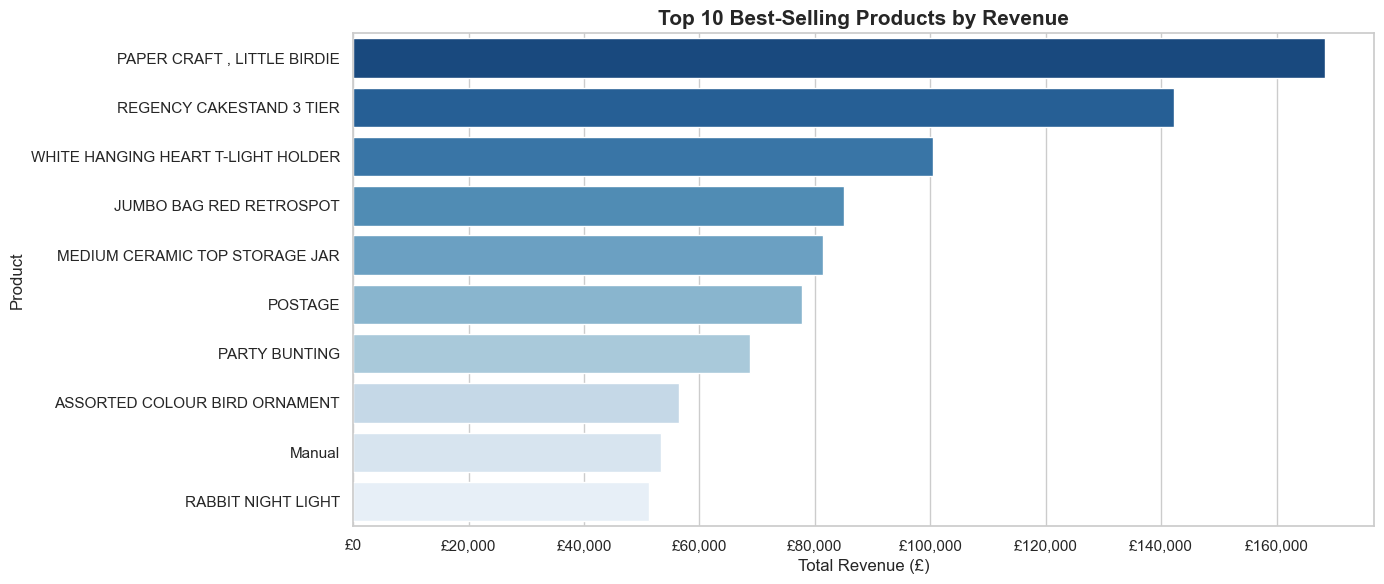

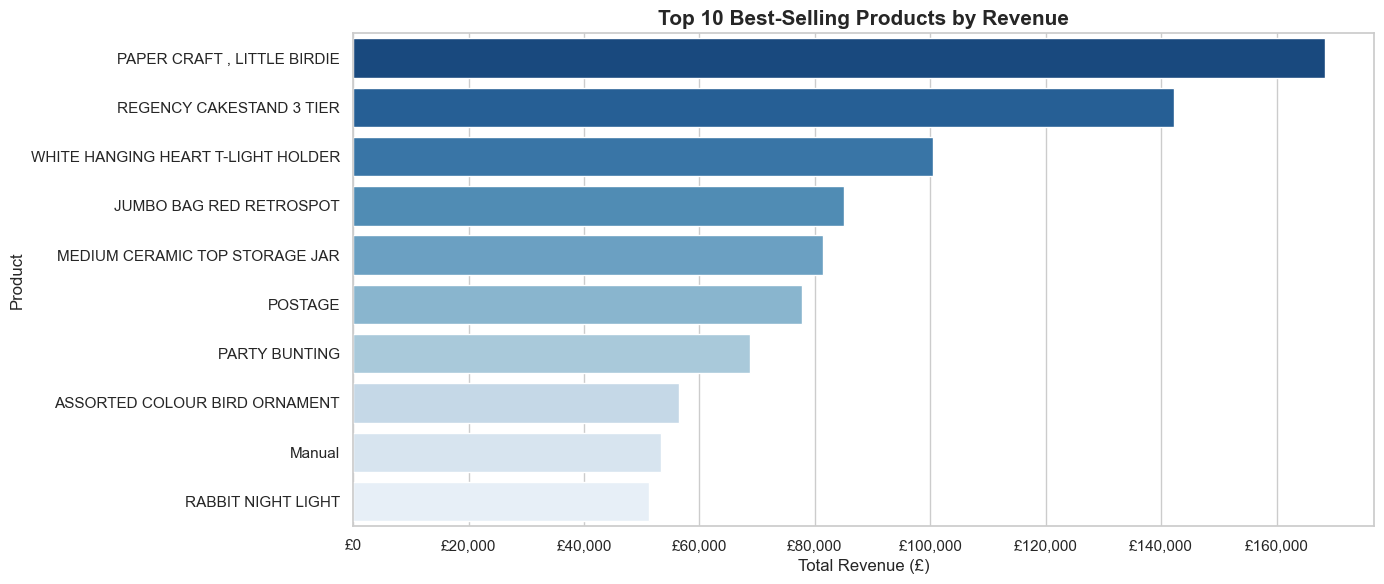

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

top_products = product_revenue.head(10)

sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r', ax=ax)

ax.set_title('Top 10 Best-Selling Products by Revenue', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
ax.set_ylabel('Product')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/top10_products_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.3.a. — Interpretation
Revenue is concentrated among a small set of home décor, kitchenware, and gift products. Consistent with the retailer's wholesale catalogue profile. PAPER CRAFT, LITTLE BIRDIE leads all products at approximately £165,000, followed closely by REGENCY CAKESTAND 3 TIER at £140,000 and WHITE HANGING HEART T-LIGHT HOLDER at £100,000. Notably, POSTAGE and Manual appear in the top 10. These are non-product entries that inflate the ranking and should be excluded from product-level recommendations. The steep revenue drop-off from the third to the tenth product confirms that a core set of three to four items drives the majority of product revenue, warranting prioritized inventory management and targeted promotional support for these lines.

### 4.4. —  Line Chart: Monthly Revenue Trend

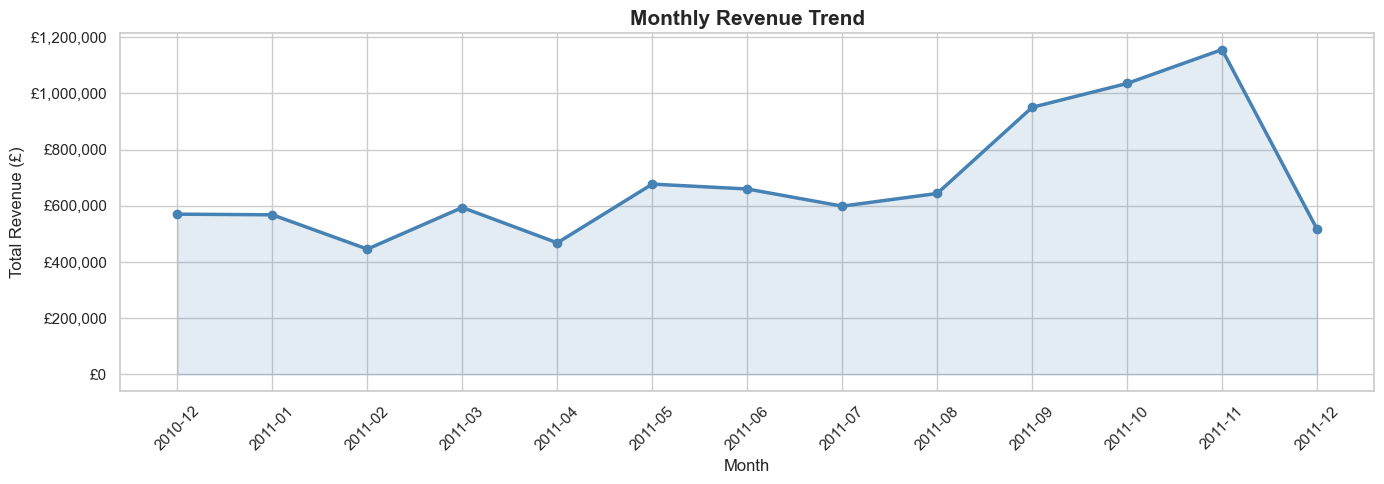

In [33]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_revenue['Month'], monthly_revenue['Revenue'],
        marker='o', linewidth=2.5, color='steelblue', markersize=6)

ax.fill_between(monthly_revenue['Month'], monthly_revenue['Revenue'],
                alpha=0.15, color='steelblue')

ax.set_title('Monthly Revenue Trend', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.4.a — Interpretation
Revenue follows a clear seasonal pattern with a strong acceleration in Q4. The first half of the year maintains relatively stable revenue between £450,000 and £680,000, with February and April representing the two weakest months at £446,085 and £468,374 respectively. From September onwards, revenue accelerates sharply by rising from £950,690 in September to a peak of £1,156,206 in November, driven by pre-holiday wholesale purchasing. December drops to £517,190, which reflects incomplete data for that month rather than an actual revenue decline. This seasonal concentration in Q4 has direct implications for inventory planning, staffing, and promotional timing.

### 4.5 — Distribution Plot: Customer Spending

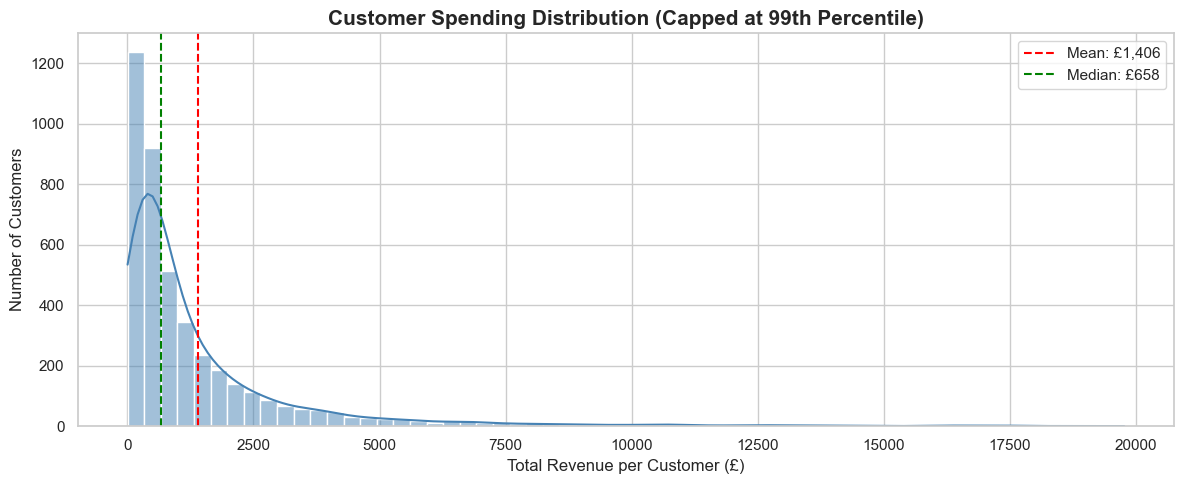

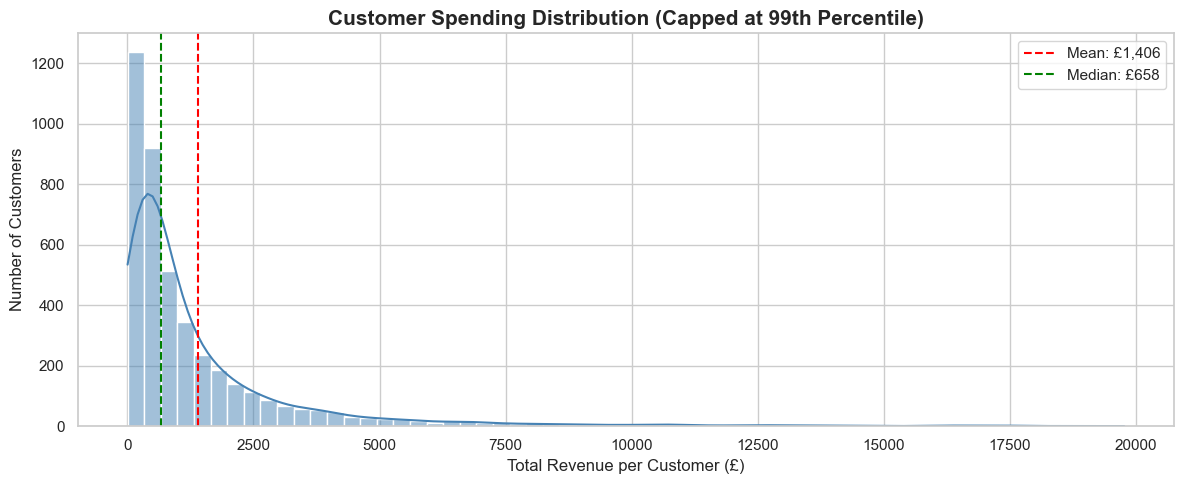

In [35]:
fig, ax = plt.subplots(figsize=(12, 5))

# Capping at 99th percentile to prevent extreme outliers from
# compressing the distribution and obscuring the typical spending pattern
cap = customer_revenue.quantile(0.99)
spending_capped = customer_revenue[customer_revenue <= cap]

sns.histplot(spending_capped, bins=60, kde=True, color='steelblue', ax=ax)

ax.axvline(spending_capped.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean: £{spending_capped.mean():,.0f}')
ax.axvline(spending_capped.median(), color='green', linestyle='--',
           linewidth=1.5, label=f'Median: £{spending_capped.median():,.0f}')

ax.set_title('Customer Spending Distribution (Capped at 99th Percentile)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Total Revenue per Customer (£)')
ax.set_ylabel('Number of Customers')
ax.legend()

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/customer_spending_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.5.a. — Interpretation
Customer spending is strongly right-skewed, as confirmed by the significant gap between the median (£658) and the mean (£1,406) within the 99th percentile cap. The majority of customers (over 1,200) cluster in the lowest spending bracket below £500, while the distribution tapers off sharply toward higher spending levels. The mean being more than double the median is the statistical signature of right skew, confirming that a small number of high-spending customers pull the average upward disproportionately. Even after capping at the 99th percentile, spending extends beyond £20,000 for a handful of customers, further illustrating the concentration of revenue in a narrow high-value segment. The median of £658 is the more representative measure of typical customer spending behavior.

### 4.6 — Box Plot: Revenue by Top 10 Countries

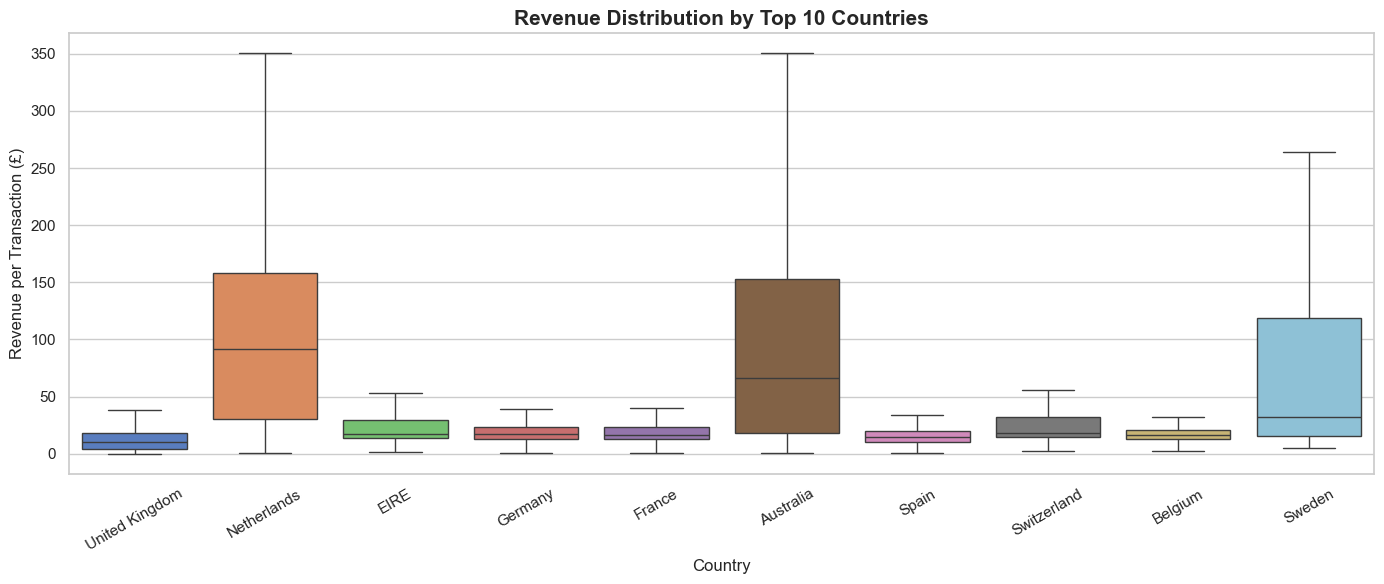

In [36]:
top_countries = country_revenue.head(10).index.tolist()
df_top = df[df['Country'].isin(top_countries)]

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(data=df_top, x='Country', y='Revenue',
            order=top_countries, palette='muted', ax=ax,
            showfliers=False)

ax.set_title('Revenue Distribution by Top 10 Countries', fontsize=15, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Revenue per Transaction (£)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/revenue_by_country_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.6.a — Interpretation
While the United Kingdom dominates total revenue at £7,285,024, its median transaction value is the lowest among all top 10 countries by sitting below £20 per transaction. This reflects the sheer volume of small, frequent domestic orders rather than high individual transaction values. In contrast, the Netherlands and Australia stand out with significantly higher median transaction values of approximately £90 and £65 respectively and wide interquartile ranges extending to £350, indicating that these markets place fewer but substantially larger orders. Sweden also shows a notably elevated median and wide spread. This pattern suggests that international customers, particularly from the Netherlands and Australia, behave as high-volume wholesale buyers placing large consolidated orders, while UK customers transact more frequently in smaller quantities. These differences have direct implications for pricing strategy and account management by market.

### 4.7 — Heatmap: Purchase Activity by Day & Hour

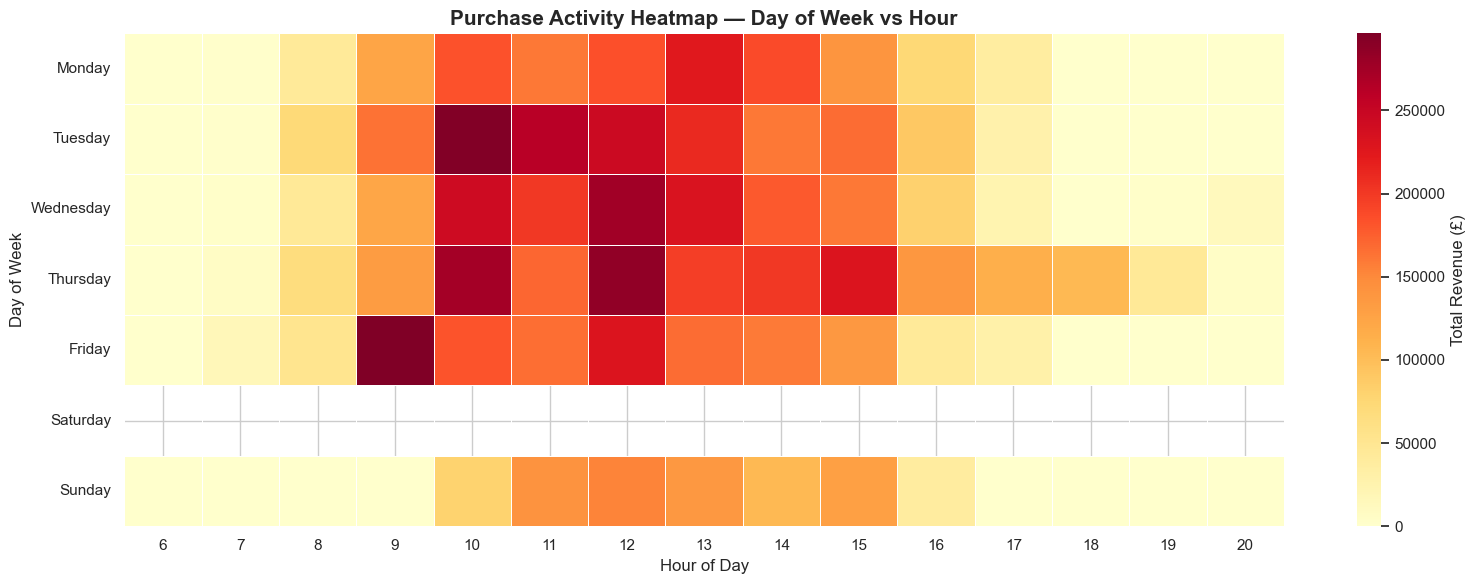

In [37]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.groupby(['DayOfWeek', 'Hour'])['Revenue'].sum().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Total Revenue (£)'})

ax.set_title('Purchase Activity Heatmap — Day of Week vs Hour',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/activity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.7.a — Interpretation
Purchase activity is firmly concentrated within weekday business hours, with peak revenue generated between 09:00 and 15:00 from Tuesday to Thursday. The darkest cells, which are representing revenue above £250,000, cluster around 09:00–13:00 on Tuesday, Wednesday, and Thursday, identifying these as the highest-value purchasing windows in the week. Friday shows an unusual early peak at 09:00, suggesting customers front-load their orders before the weekend. Saturday shows near-zero activity across all hours, and Sunday, while showing some mid-day activity between 10:00 and 15:00, remains significantly below weekday levels. Thursday stands out as the only day with meaningful evening activity extending to 19:00–20:00. This weekday concentration strongly confirms a B2B wholesale customer base operating on standard business schedules, with Tuesday to Thursday mornings representing the optimal window for time-sensitive promotions and outreach campaigns.